Load Data from GitHub

In [1]:
import pandas as pd
import numpy as np

github_url = "https://raw.githubusercontent.com/tarshibofficial/Ai-ML-Assignment-3/main/Dataset/diabetes%20%281%29%20%281%29.csv"

df = pd.read_csv(github_url)

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Dataset Information

In [2]:
print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nDataset Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (768, 9)

Columns:
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

Missing Values:
Pregnancies  

Separate Features (X) and Target (y)

In [3]:
if 'Outcome' in df.columns:
    target_col = 'Outcome'
else:
    target_col = df.columns[-1]

X = df.drop(target_col, axis=1)
y = df[target_col]

print("Target column:", target_col)
print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Target column: Outcome
Feature shape: (768, 8)
Target shape: (768,)


Target Distribution

In [4]:
target_names = ['No Diabetes', 'Diabetes']

print("\nTarget distribution:")
print(y.value_counts())

print("\nClass Balance:")
for i, name in enumerate(target_names):
    count = (y == i).sum()
    percentage = (count / len(y)) * 100
    print(f"  {name}: {count} ({percentage:.2f}%)")


Target distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

Class Balance:
  No Diabetes: 500 (65.10%)
  Diabetes: 268 (34.90%)


Target Distribution

In [5]:
target_names = ['No Diabetes', 'Diabetes']

print("\nTarget distribution:")
print(y.value_counts())

print("\nClass Balance:")
for i, name in enumerate(target_names):
    count = (y == i).sum()
    percentage = (count / len(y)) * 100
    print(f"  {name}: {count} ({percentage:.2f}%)")


Target distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

Class Balance:
  No Diabetes: 500 (65.10%)
  Diabetes: 268 (34.90%)


Train/Test Split

In [7]:
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (614, 8)
Testing set: (154, 8)


CART Implementation — Gini Criterion

In [8]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

param_grid_cart = {
    'max_depth': [3, 5, 7, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8]
}

cart_model = DecisionTreeClassifier(criterion='gini', random_state=42)

grid_search_cart = GridSearchCV(
    cart_model,
    param_grid_cart,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

grid_search_cart.fit(X_train, y_train)

best_cart = grid_search_cart.best_estimator_

print("CART Grid Search Complete!")
print("Best Parameters for CART:")
for param, value in grid_search_cart.best_params_.items():
    print(f"  {param}: {value}")

print(f"Best CV Accuracy (CART): {grid_search_cart.best_score_:.4f}")

Fitting 5 folds for each of 112 candidates, totalling 560 fits
CART Grid Search Complete!
Best Parameters for CART:
  max_depth: 3
  min_samples_leaf: 4
  min_samples_split: 20
Best CV Accuracy (CART): 0.7509


ID3 Implementation — Entropy Criterion

In [9]:
param_grid_id3 = {
    'max_depth': [3, 5, 7, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8]
}

id3_model = DecisionTreeClassifier(criterion='entropy', random_state=42)

grid_search_id3 = GridSearchCV(
    id3_model,
    param_grid_id3,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

grid_search_id3.fit(X_train, y_train)

best_id3 = grid_search_id3.best_estimator_

print("ID3 Grid Search Complete!")
print("Best Parameters for ID3:")
for param, value in grid_search_id3.best_params_.items():
    print(f"  {param}: {value}")

print(f"Best CV Accuracy (ID3): {grid_search_id3.best_score_:.4f}")

Fitting 5 folds for each of 112 candidates, totalling 560 fits
ID3 Grid Search Complete!
Best Parameters for ID3:
  max_depth: 3
  min_samples_leaf: 8
  min_samples_split: 2
Best CV Accuracy (ID3): 0.7558


Evaluation Metrics — CART

In [10]:
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve,
    auc, roc_auc_score, accuracy_score, precision_score,
    recall_score, f1_score
)

y_pred_cart = best_cart.predict(X_test)
y_pred_proba_cart = best_cart.predict_proba(X_test)[:, 1]

cart_accuracy = accuracy_score(y_test, y_pred_cart)
cart_precision = precision_score(y_test, y_pred_cart, zero_division=0)
cart_recall = recall_score(y_test, y_pred_cart, zero_division=0)
cart_f1 = f1_score(y_test, y_pred_cart, zero_division=0)
cart_auc = roc_auc_score(y_test, y_pred_proba_cart)

print("\n--- CART (Gini) Metrics ---")
print(f"Accuracy:  {cart_accuracy:.4f}")
print(f"Precision: {cart_precision:.4f}")
print(f"Recall:    {cart_recall:.4f}")
print(f"F1-Score:  {cart_f1:.4f}")
print(f"AUC:       {cart_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_cart, target_names=target_names))


--- CART (Gini) Metrics ---
Accuracy:  0.7013
Precision: 0.6818
Recall:    0.2778
F1-Score:  0.3947
AUC:       0.7893

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.70      0.93      0.80       100
    Diabetes       0.68      0.28      0.39        54

    accuracy                           0.70       154
   macro avg       0.69      0.60      0.60       154
weighted avg       0.70      0.70      0.66       154



Evaluation Metrics — ID3

In [11]:
y_pred_id3 = best_id3.predict(X_test)
y_pred_proba_id3 = best_id3.predict_proba(X_test)[:, 1]

id3_accuracy = accuracy_score(y_test, y_pred_id3)
id3_precision = precision_score(y_test, y_pred_id3, zero_division=0)
id3_recall = recall_score(y_test, y_pred_id3, zero_division=0)
id3_f1 = f1_score(y_test, y_pred_id3, zero_division=0)
id3_auc = roc_auc_score(y_test, y_pred_proba_id3)

print("\n--- ID3 (Entropy) Metrics ---")
print(f"Accuracy:  {id3_accuracy:.4f}")
print(f"Precision: {id3_precision:.4f}")
print(f"Recall:    {id3_recall:.4f}")
print(f"F1-Score:  {id3_f1:.4f}")
print(f"AUC:       {id3_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_id3, target_names=target_names))


--- ID3 (Entropy) Metrics ---
Accuracy:  0.6948
Precision: 0.6522
Recall:    0.2778
F1-Score:  0.3896
AUC:       0.7956

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.70      0.92      0.80       100
    Diabetes       0.65      0.28      0.39        54

    accuracy                           0.69       154
   macro avg       0.68      0.60      0.59       154
weighted avg       0.68      0.69      0.65       154



Confusion Matrix

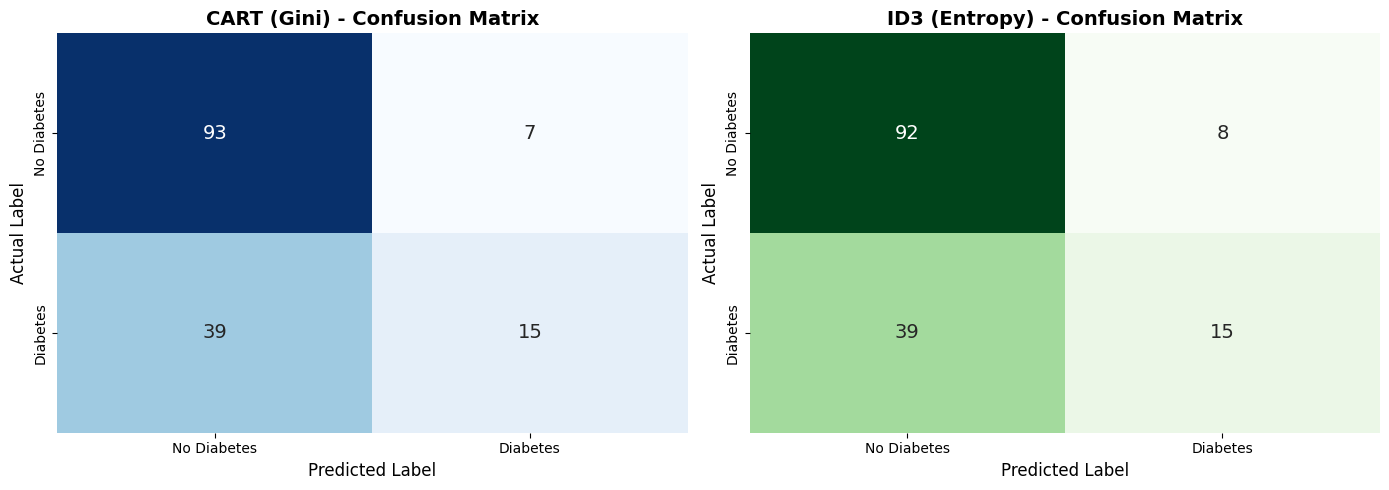

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CART Confusion Matrix
cm_cart = confusion_matrix(y_test, y_pred_cart)
sns.heatmap(
    cm_cart,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=target_names,
    yticklabels=target_names,
    annot_kws={'size': 14},
    ax=axes[0]
)

axes[0].set_title('CART (Gini) - Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Actual Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)

# ID3 Confusion Matrix
cm_id3 = confusion_matrix(y_test, y_pred_id3)
sns.heatmap(
    cm_id3,
    annot=True,
    fmt='d',
    cmap='Greens',
    cbar=False,
    xticklabels=target_names,
    yticklabels=target_names,
    annot_kws={'size': 14},
    ax=axes[1]
)

axes[1].set_title('ID3 (Entropy) - Confusion Matrix', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Actual Label', fontsize=12)
axes[1].set_xlabel('Predicted Label', fontsize=12)

plt.tight_layout()
plt.savefig('2_Confusion_Matrix.png', dpi=300, bbox_inches='tight')
plt.show()

ROC Curve

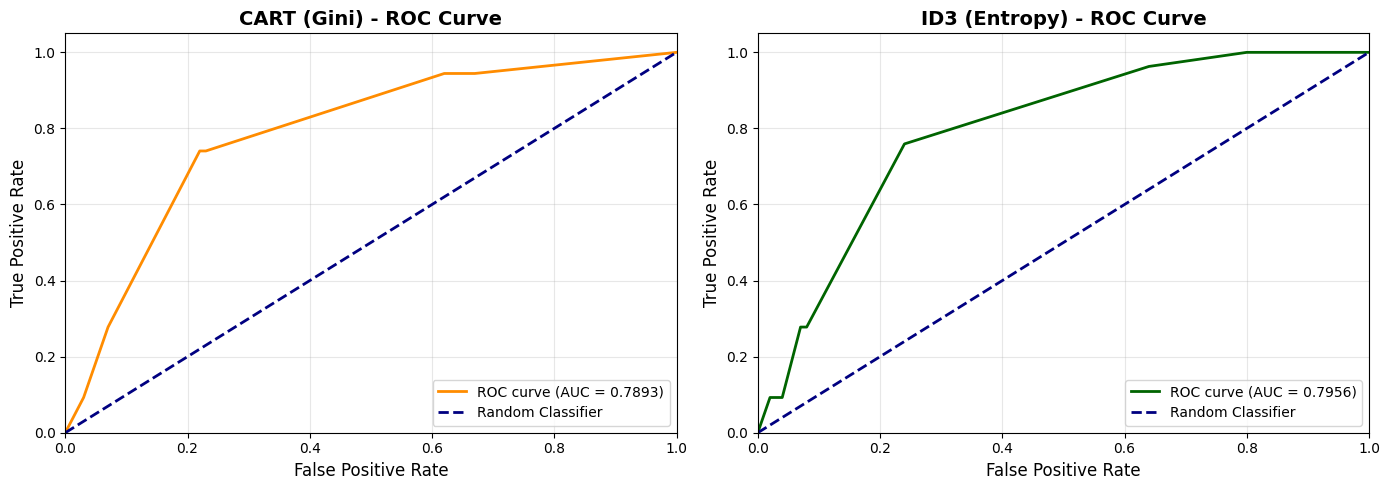

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CART ROC Curve
fpr_cart, tpr_cart, _ = roc_curve(y_test, y_pred_proba_cart)
roc_auc_cart = auc(fpr_cart, tpr_cart)

axes[0].plot(fpr_cart, tpr_cart, color='darkorange', lw=2,
             label=f'ROC curve (AUC = {roc_auc_cart:.4f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
             label='Random Classifier')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('CART (Gini) - ROC Curve', fontsize=14, fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# ID3 ROC Curve
fpr_id3, tpr_id3, _ = roc_curve(y_test, y_pred_proba_id3)
roc_auc_id3 = auc(fpr_id3, tpr_id3)

axes[1].plot(fpr_id3, tpr_id3, color='darkgreen', lw=2,
             label=f'ROC curve (AUC = {roc_auc_id3:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
             label='Random Classifier')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('ID3 (Entropy) - ROC Curve', fontsize=14, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('3_ROC_Curve.png', dpi=300, bbox_inches='tight')
plt.show()

2D Decision Boundary Visualization

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/tmp/ipykernel_3603/3458114698.py:69: MatplotlibDeprecationWarning: You have mixed positional and keyword arguments, some input may be discarded.  This is deprecated since 3.9 and will become an error in 3.11.
  axes[0].legend(*scatter1.legend_elements(), title="Classes", labels=target_names)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/tmp/ipykernel_3603/3458114698.py:90: MatplotlibDeprecationWarning: You have mixed positional and keyword arguments, some input may be discarded.  This is deprecated since 3.9 and will become an error in 3.11.
  axes[1].legend(*scatter2.legend_elements(), title="Classes", labels=target_names)


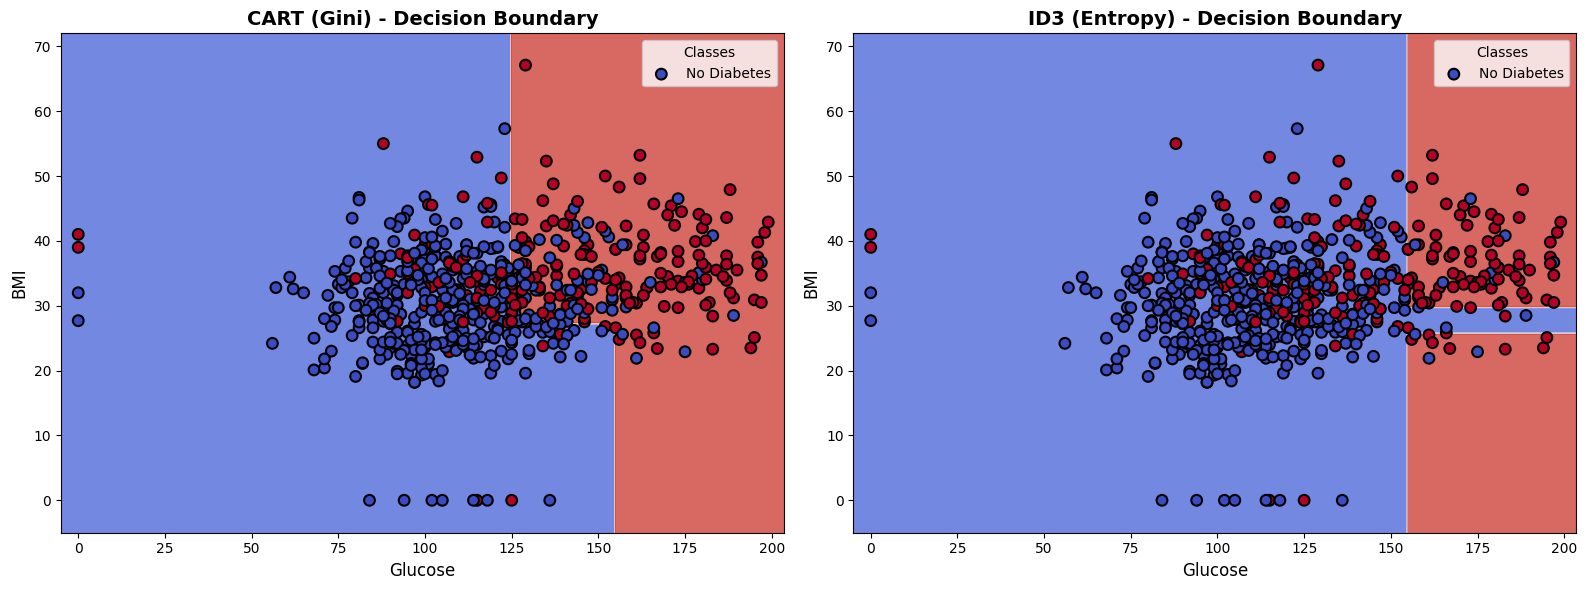

In [14]:
import matplotlib.pyplot as plt

preferred_features = ['Glucose', 'BMI']

if all(feature in X.columns for feature in preferred_features):
    features_2D = preferred_features
else:
    features_2D = list(X.select_dtypes(include=[np.number]).columns[:2])

X_2D = X[features_2D]

X_train_2D, X_test_2D, y_train_2D, y_test_2D = train_test_split(
    X_2D, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

cart_2D = DecisionTreeClassifier(
    criterion='gini',
    max_depth=best_cart.max_depth,
    min_samples_split=best_cart.min_samples_split,
    min_samples_leaf=best_cart.min_samples_leaf,
    random_state=42
)

cart_2D.fit(X_train_2D, y_train_2D)

id3_2D = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=best_id3.max_depth,
    min_samples_split=best_id3.min_samples_split,
    min_samples_leaf=best_id3.min_samples_leaf,
    random_state=42
)

id3_2D.fit(X_train_2D, y_train_2D)

h = 0.5
x_min, x_max = X_train_2D.iloc[:, 0].min() - 5, X_train_2D.iloc[:, 0].max() + 5
y_min, y_max = X_train_2D.iloc[:, 1].min() - 5, X_train_2D.iloc[:, 1].max() + 5

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# CART Decision Boundary
Z_cart = cart_2D.predict(np.c_[xx.ravel(), yy.ravel()])
Z_cart = Z_cart.reshape(xx.shape)

axes[0].contourf(xx, yy, Z_cart, alpha=0.8, cmap=plt.cm.coolwarm)
scatter1 = axes[0].scatter(
    X_train_2D.iloc[:, 0],
    X_train_2D.iloc[:, 1],
    c=y_train_2D,
    cmap=plt.cm.coolwarm,
    edgecolors='k',
    marker='o',
    s=60,
    linewidth=1.5
)

axes[0].set_title('CART (Gini) - Decision Boundary', fontsize=14, fontweight='bold')
axes[0].set_xlabel(features_2D[0], fontsize=12)
axes[0].set_ylabel(features_2D[1], fontsize=12)
axes[0].legend(*scatter1.legend_elements(), title="Classes", labels=target_names)

# ID3 Decision Boundary
Z_id3 = id3_2D.predict(np.c_[xx.ravel(), yy.ravel()])
Z_id3 = Z_id3.reshape(xx.shape)

axes[1].contourf(xx, yy, Z_id3, alpha=0.8, cmap=plt.cm.coolwarm)
scatter2 = axes[1].scatter(
    X_train_2D.iloc[:, 0],
    X_train_2D.iloc[:, 1],
    c=y_train_2D,
    cmap=plt.cm.coolwarm,
    edgecolors='k',
    marker='o',
    s=60,
    linewidth=1.5
)

axes[1].set_title('ID3 (Entropy) - Decision Boundary', fontsize=14, fontweight='bold')
axes[1].set_xlabel(features_2D[0], fontsize=12)
axes[1].set_ylabel(features_2D[1], fontsize=12)
axes[1].legend(*scatter2.legend_elements(), title="Classes", labels=target_names)

plt.tight_layout()
plt.savefig('1_Decision_Boundary.png', dpi=300, bbox_inches='tight')
plt.show()

Evaluation Metrics Comparison

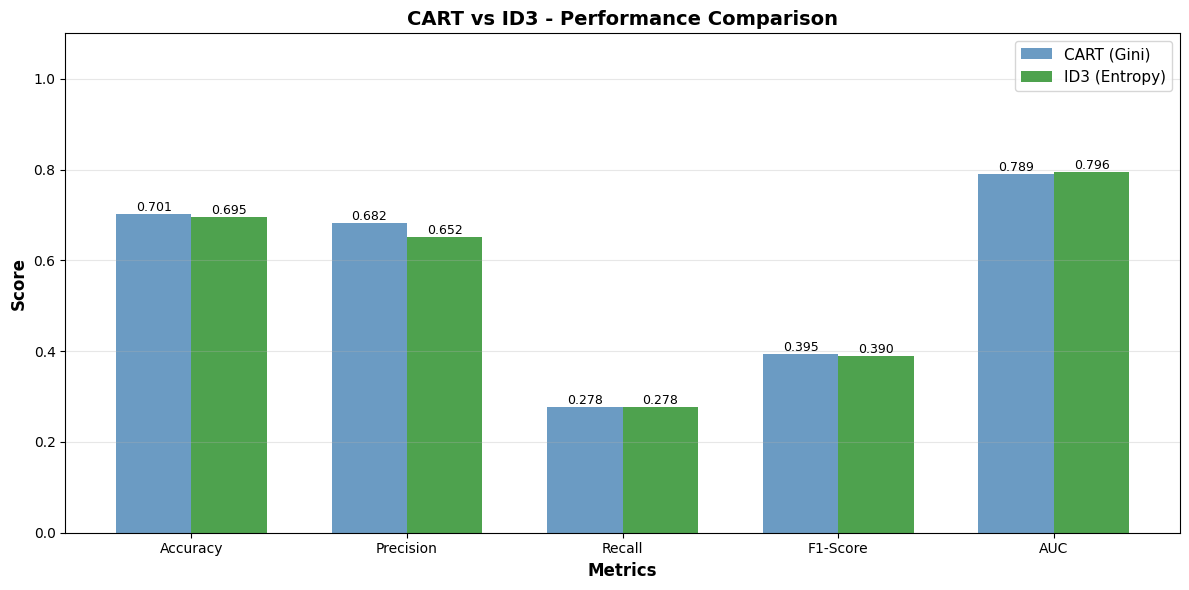

In [15]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']

cart_scores = [
    cart_accuracy,
    cart_precision,
    cart_recall,
    cart_f1,
    cart_auc
]

id3_scores = [
    id3_accuracy,
    id3_precision,
    id3_recall,
    id3_f1,
    id3_auc
]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - width/2, cart_scores, width, label='CART (Gini)',
               color='steelblue', alpha=0.8)

bars2 = ax.bar(x + width/2, id3_scores, width, label='ID3 (Entropy)',
               color='forestgreen', alpha=0.8)

ax.set_xlabel('Metrics', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('CART vs ID3 - Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.tight_layout()
plt.savefig('4_Evaluation_Metrics.png', dpi=300, bbox_inches='tight')
plt.show()

Decision Tree Structure

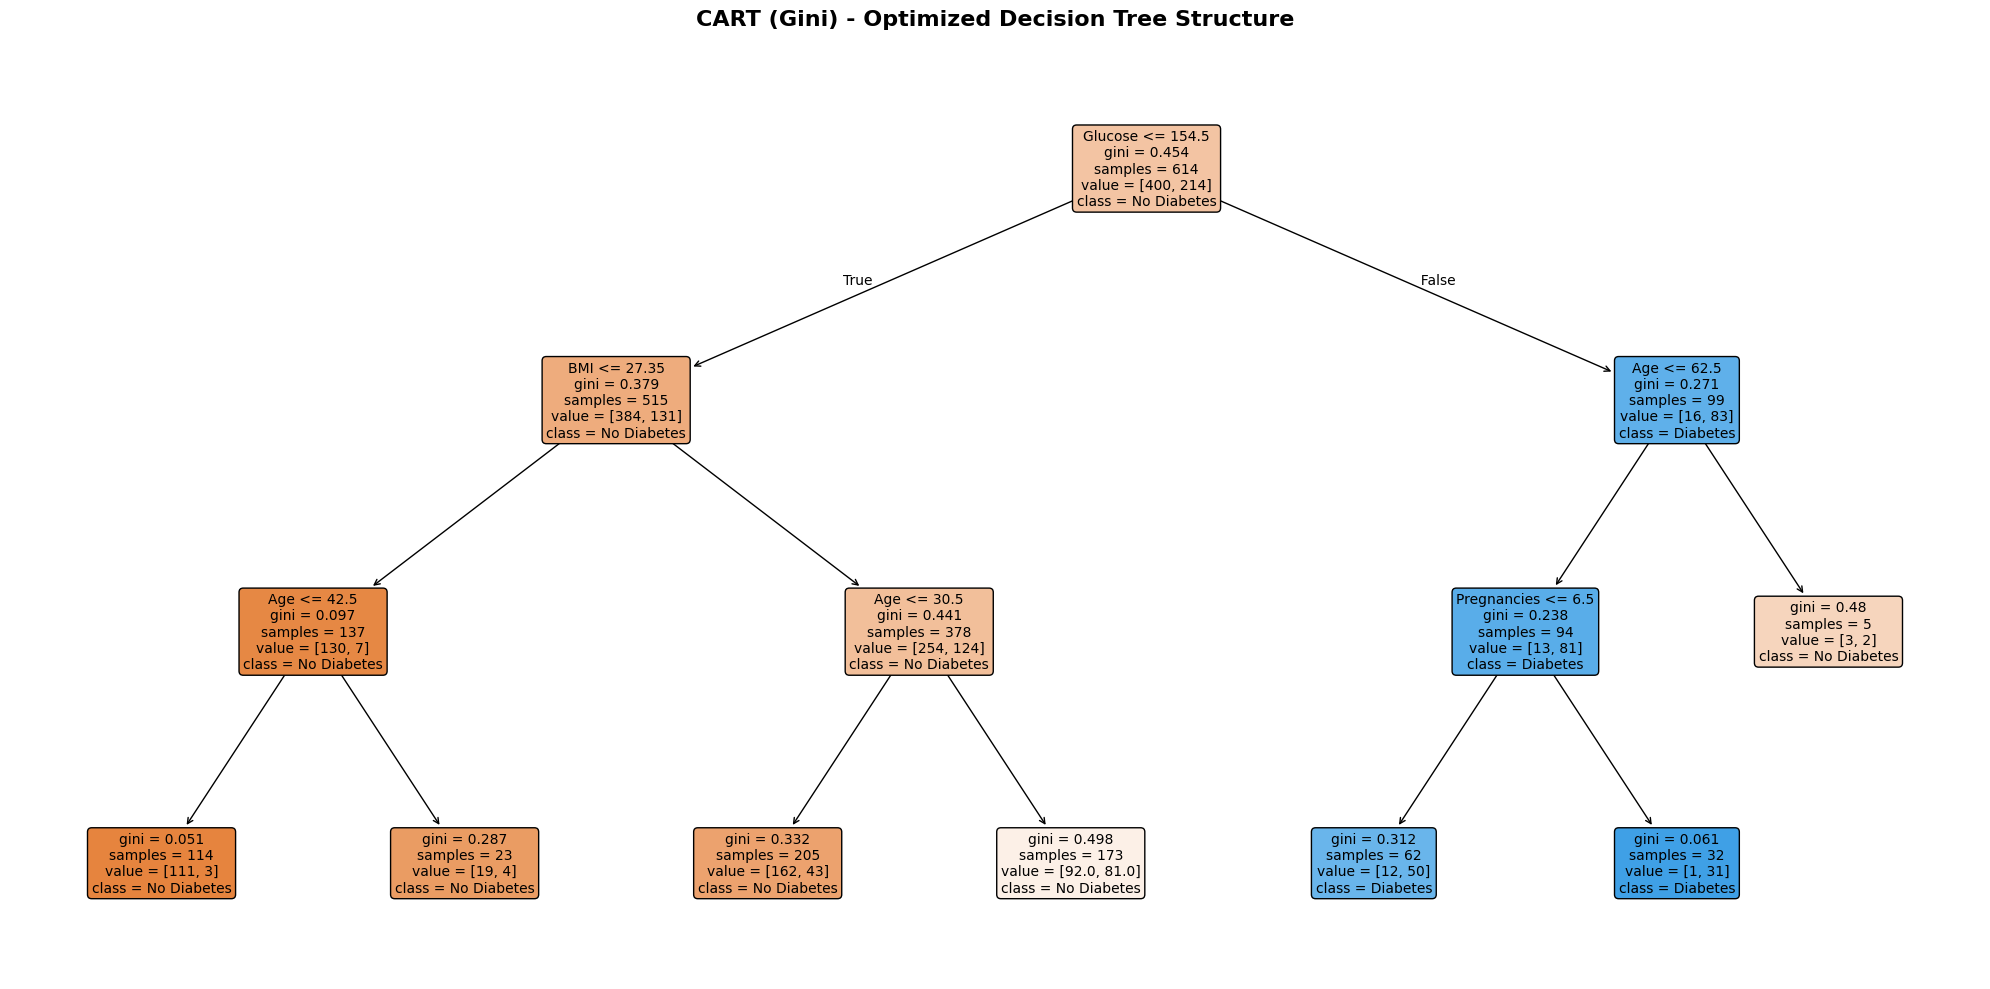

In [16]:
fig, ax = plt.subplots(figsize=(20, 10))

plot_tree(
    best_cart,
    feature_names=X.columns,
    class_names=target_names,
    filled=True,
    rounded=True,
    fontsize=10,
    ax=ax
)

ax.set_title(
    'CART (Gini) - Optimized Decision Tree Structure',
    fontsize=16,
    fontweight='bold',
    pad=20
)

plt.tight_layout()
plt.savefig('5_decisionTree.png', dpi=300, bbox_inches='tight')
plt.show()

Final Model Comparison Summary

In [17]:
comparison_df = pd.DataFrame({
    'Metric': metrics,
    'CART (Gini)': cart_scores,
    'ID3 (Entropy)': id3_scores
})

print("Model Performance Comparison:")
display(comparison_df)

if cart_accuracy > id3_accuracy:
    print("\nCART (Gini) performed better based on Accuracy.")
elif id3_accuracy > cart_accuracy:
    print("\nID3 (Entropy) performed better based on Accuracy.")
else:
    print("\nBoth models achieved the same Accuracy.")

Model Performance Comparison:


,Metric,CART (Gini),ID3 (Entropy)
0,Accuracy,0.701299,0.694805
1,Precision,0.681818,0.652174
2,Recall,0.277778,0.277778
3,F1-Score,0.394737,0.389610
4,AUC,0.789259,0.795556



CART (Gini) performed better based on Accuracy.
